In [1]:
%matplotlib inline
import numpy as np
import scipy.linalg as la
import cvxpy as cvx
import pandas as pd
from formulaic import model_matrix #for regression formulas
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
# Equality Constrained Least Squares
np.random.seed(0)
df = pd.DataFrame({'x':np.random.normal(size=(1000))})
xmm = model_matrix('~poly(x, 8)', data=df)
spec = xmm.model_spec #extract transformations so we can apply them to a new dataframe
xfull = xmm.to_numpy()
#now separate into high quality and low quality observations
is_high_quality = np.random.binomial(n=1, size=xfull.shape[0], p=.007).astype(bool)
beta = np.random.normal(size=xfull.shape[1])
xtilde = xfull[is_high_quality,:]
x = xfull[~is_high_quality,:]
ytilde = xtilde @ beta
y = x @ beta + np.random.normal(loc=0.0, scale=0.1, size=x.shape[0])

In [3]:
#here we have data matrices, which are (unusually for an optimization problem) not sparse
A = np.bmat([[x.T @ x, xtilde.T], [xtilde, np.zeros((xtilde.shape[0], xtilde.shape[0]))]])
b = np.concatenate([x.T @ y, ytilde])
soln = la.solve(A, b, assume_a='sym')

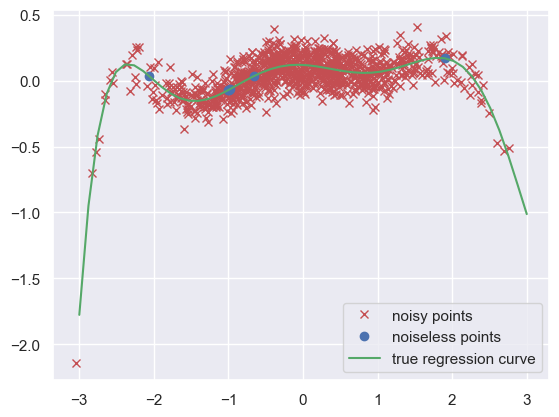

In [4]:
plt.plot(df['x'].to_numpy()[~is_high_quality], y, 'rx', label='noisy points')
plt.plot(df['x'].to_numpy()[is_high_quality], ytilde, 'bo', label='noiseless points')
range_df = pd.DataFrame({'x':np.linspace(-3,3)})
range_x = spec.get_model_matrix(range_df).to_numpy()
plt.plot(range_df['x'], range_x @ beta, 'g-', label='true regression curve')
plt.legend()
plt.show()

In [5]:
#optimal control example from notes
T = 100 #number of timesteps
d = 3 #dimension of problem
S = 10
Ss = np.arange(0, 100, 10)
ws = np.random.normal(size=(S,d)).ravel()

In [6]:
B = np.eye(T*d)
np.fill_diagonal(B[3:,:], -1.)
mI = -np.eye(T*d)
SI = np.zeros((d*S, d*T))
for i, s in enumerate(Ss):
    for t in range(d):
        SI[d*i+t,d*s+t] = 1.0
K = np.bmat(
    [[B, mI, np.zeros((T*d, T*d))],
     [np.zeros((T*d, T*d)), B, mI],
     [SI, np.zeros((S*d, T*d)), np.zeros((S*d, T*d))]]
)

In [7]:
gravity = np.zeros(T*d)
gravity[2::3] = -9.81
b = np.concatenate([np.zeros(T*d), gravity, ws])
rhs = np.concatenate([np.zeros(3*d*T), b])

In [8]:
A = np.zeros((3*d*T, 3*d*T))
for i in range(2*d*T, 3*d*T):
    A[i,i] = 1.
M = np.bmat([[A, K.T], [K, np.zeros((K.shape[0], K.shape[0]))]])
soln = la.solve(M, rhs, assume_a='sym')

In [9]:
x = soln[:d*T].reshape(T, d)

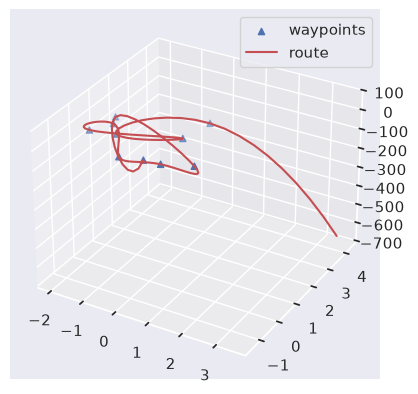

In [ ]:
#3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ws = ws.reshape(S, d)
ax.scatter(ws[:,0], ws[:,1], ws[:,2], marker='^', label='waypoints')
ax.plot(x[:,0], x[:,1], x[:,2], color='r', label='route')
plt.legend()
plt.show() 
#whoops! 
#We didn't specify a terminal pt so we just let drone fall after making last waypoint